In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargar el dataset limpio que generamos en el ETL
df_clean = pd.read_csv('train_clean.csv')

# Verificar que cargó correctamente
df_clean.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Alto_Riesgo
0,1,male,44,1,28.0,0,> 2 years,yes,40454.0,26.0,217,1,41-50 años,1
1,2,male,76,1,3.0,0,1-2 year,no,33536.0,26.0,183,0,60+ años,0
2,3,male,47,1,28.0,0,> 2 years,yes,38294.0,26.0,27,1,41-50 años,1
3,4,male,21,1,11.0,1,< 1 year,no,28619.0,152.0,203,0,20-30 años,0
4,5,female,29,1,41.0,1,< 1 year,no,27496.0,152.0,39,0,20-30 años,0


<h2 style="color: #2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
  📈 Análisis Exploratorio de Datos (EDA)
</h2>
<p>
  En esta fase, analizaremos el dataset limpio para responder a las preguntas de negocio clave, identificando patrones de comportamiento y segmentando a los clientes con mayor propensión a la compra.
</p>

<h3 style="color: #117A65; padding-top: 10px;">
  1. Impacto del Daño del Vehículo en la Conversión
</h3>

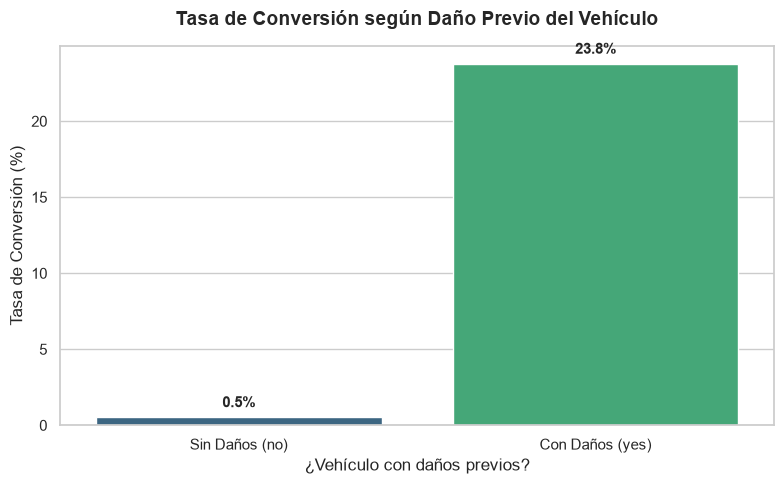

In [15]:
# Calculamos la tasa de conversión (porcentaje de Response = 1) según daño previo
conversion_dano = df_clean.groupby('Vehicle_Damage')['Response'].mean() * 100

# Configuramos el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Creamos un gráfico de barras mapeando directamente los nombres limpios en el eje X
ax = sns.barplot(
    x=['Sin Daños (no)', 'Con Daños (yes)'], 
    y=conversion_dano.values, 
    hue=['Sin Daños (no)', 'Con Daños (yes)'], 
    palette='viridis', 
    legend=False
)

# Personalizamos títulos y etiquetas
plt.title('Tasa de Conversión según Daño Previo del Vehículo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('¿Vehículo con daños previos?', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Agregamos los porcentajes arriba de cada barra para facilitar la lectura
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

# Ajustamos los márgenes y mostramos el gráfico limpio
plt.tight_layout()
plt.show()

<div style="background-color: #EAFAF1; border-left: 4px solid #27AE60; padding: 12px; border-radius: 4px; margin-top: 15px;">
  <p style="color: #145A32; margin: 0; font-family: sans-serif;">
    💡 <strong>Insight de Negocio:</strong> Existe una diferencia drástica en la propensión de compra. Los clientes con <strong>vehículos dañados previamente</strong> registran una conversión del <strong>23.8%</strong>, frente a un magro <strong>0.5%</strong> en clientes sin daños. Esto demuestra que la venta cruzada no se impulsa por el producto en sí, sino por la conciencia de riesgo y la experiencia previa del siniestro.
  </p>
</div>

<h3 style="color: #117A65; padding-top: 15px;">
  2. Rendimiento de los Canales de Venta según la Edad del Afiliado
</h3>
<p>
  Analizamos qué canales comerciales concentran las mayores conversiones exitosas (<code>Response = 1</code>) para entender las preferencias de contacto de nuestros afiliados.
</p>

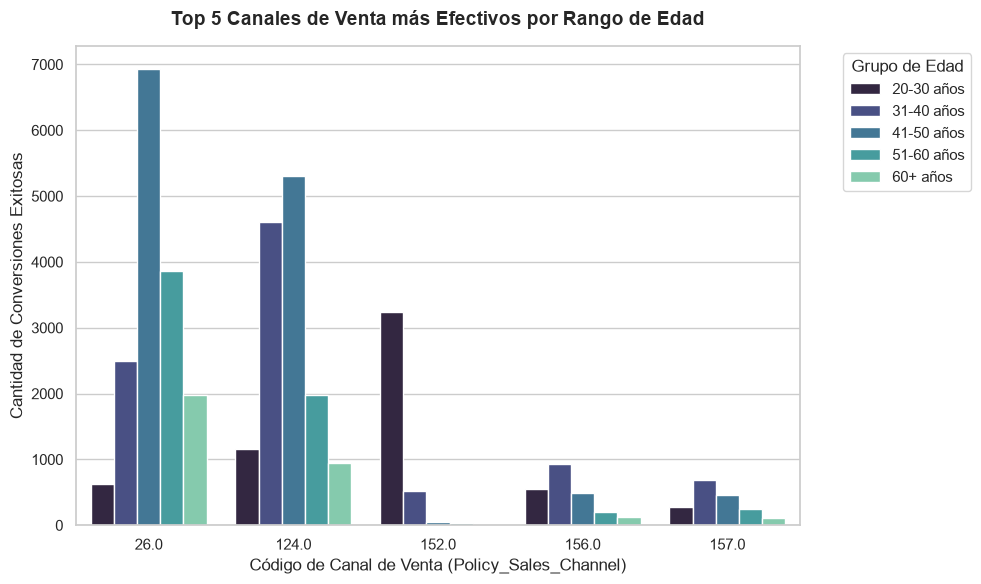

In [16]:
# Filtramos solo a los clientes que aceptaron la oferta (Response == 1)
df_convertidos = df_clean[df_clean['Response'] == 1]

# Agrupamos por canal de venta y rango de edad para ver el volumen de ventas cruzadas
ventas_canal_edad = df_convertidos.groupby(['Policy_Sales_Channel', 'Age_Group']).size().reset_index(name='Total_Ventas')

# Nos quedamos con los 5 canales de venta principales para que el gráfico sea claro y limpio
top_canales = df_convertidos['Policy_Sales_Channel'].value_counts().head(5).index
ventas_top = ventas_canal_edad[ventas_canal_edad['Policy_Sales_Channel'].isin(top_canales)]

# Configuramos el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ventas_top, 
    x='Policy_Sales_Channel', 
    y='Total_Ventas', 
    hue='Age_Group', 
    palette='mako'
)

# Personalización
plt.title('Top 5 Canales de Venta más Efectivos por Rango de Edad', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Código de Canal de Venta (Policy_Sales_Channel)', fontsize=12)
plt.ylabel('Cantidad de Conversiones Exitosas', fontsize=12)
plt.legend(title='Grupo de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<div style="background-color: #EAFAF1; border-left: 4px solid #27AE60; padding: 12px; border-radius: 4px; margin-top: 15px;">
  <p style="color: #145A32; margin: 0; font-family: sans-serif;">
    💡 <strong>Insight de Negocio:</strong> El rendimiento comercial está fuertemente concentrado en canales específicos (como los canales principales con mayor volumen). Además, se observa que los grupos etarios intermedios y adultos (como el rango de <strong>41 a 50 años</strong> y <strong>31 a 40 años</strong>) lideran la adopción del seguro vehicular en comparación con los extremos de edad, lo que sugiere direccionar las llamadas o pautas digitales hacia estos segmentos productivos.
  </p>
</div>

<h3 style="color: #117A65; padding-top: 15px;">
  3. Impacto de la Tenencia Previa de Seguros en la Conversión
</h3>
<p>
  Analizamos cómo el hecho de contar o no con una póliza previa (<code>Previously_Insured</code>) determina la efectividad de nuestra campaña de venta cruzada.
</p>

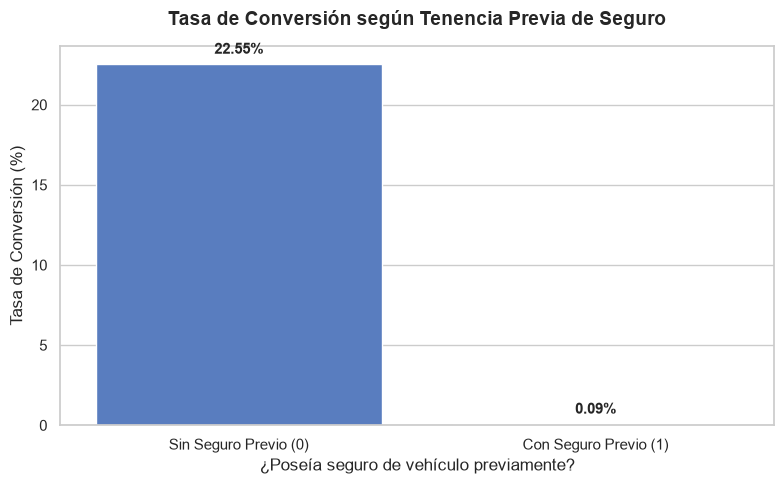

In [17]:
# Calculamos la tasa de conversión según si ya tenían seguro previo o no
conversion_seguro = df_clean.groupby('Previously_Insured')['Response'].mean() * 100

# Configuramos el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Creamos el gráfico de barras
ax = sns.barplot(
    x=['Sin Seguro Previo (0)', 'Con Seguro Previo (1)'], 
    y=conversion_seguro.values, 
    hue=['Sin Seguro Previo (0)', 'Con Seguro Previo (1)'], 
    palette='muted', 
    legend=False
)

# Personalización
plt.title('Tasa de Conversión según Tenencia Previa de Seguro', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('¿Poseía seguro de vehículo previamente?', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Agregamos los porcentajes arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

<div style="background-color: #EAFAF1; border-left: 4px solid #27AE60; padding: 12px; border-radius: 4px; margin-top: 15px;">
  <p style="color: #145A32; margin: 0; font-family: sans-serif;">
    💡 <strong>Insight de Negocio:</strong> Existe una segmentación excluyente y absoluta. La tasa de conversión se desploma al <strong>0.09%</strong> en clientes que ya poseen una póliza previa, mientras que trepa al <strong>22.5%</strong> en aquellos que carecen de cobertura. <strong>Conclusión estratégica:</strong> El departamento de marketing debe excluir por completo de las pautas comerciales a los clientes ya asegurados, concentrando el 100% de los esfuerzos y presupuesto en el segmento desprotegido.
  </p>
</div>

<h3 style="color: #117A65; padding-top: 15px;">
  4. Segmentación Estratégica: El Impacto del Indicador de Alto Riesgo Combinado
</h3>
<p>
  Evaluamos la efectividad de nuestra nueva variable derivada (<code>Alto_Riesgo</code>), que cruza de forma quirúrgica a quienes sufrieron daños previos y no poseen un seguro contratado.
</p>

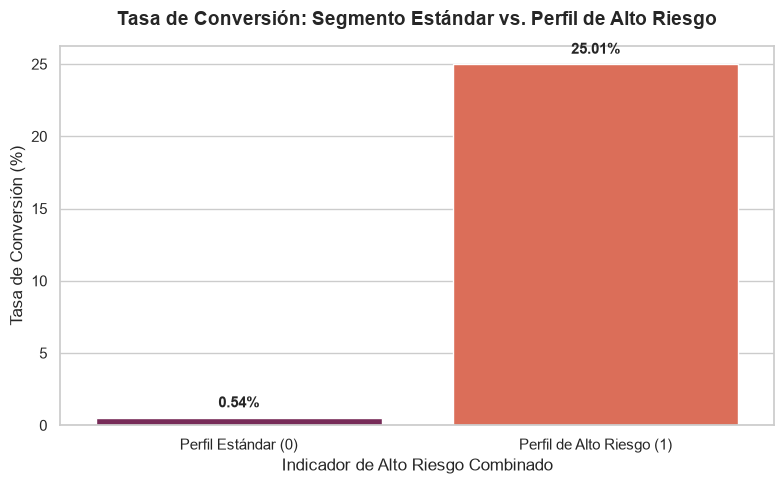

In [18]:
# Calculamos la tasa de conversión según el indicador de alto riesgo
conversion_riesgo = df_clean.groupby('Alto_Riesgo')['Response'].mean() * 100

# Configuramos el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Creamos el gráfico de barras
ax = sns.barplot(
    x=['Perfil Estándar (0)', 'Perfil de Alto Riesgo (1)'], 
    y=conversion_riesgo.values, 
    hue=['Perfil Estándar (0)', 'Perfil de Alto Riesgo (1)'], 
    palette='rocket', 
    legend=False
)

# Personalización
plt.title('Tasa de Conversión: Segmento Estándar vs. Perfil de Alto Riesgo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Indicador de Alto Riesgo Combinado', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Agregamos los porcentajes arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

<div style="background-color: #EAFAF1; border-left: 4px solid #27AE60; padding: 12px; border-radius: 4px; margin-top: 15px;">
  <p style="color: #145A32; margin: 0; font-family: sans-serif;">
    💡 <strong>Insight de Negocio (Gran Conclusión):</strong> La creación de esta característica derivada demuestra que la combinación de variables maximiza el rendimiento comercial. Mientras que el segmento estándar registra un magro <strong>0.54%</strong> de conversión, el <strong>Perfil de Alto Riesgo</strong> dispara la aceptación de la oferta hasta un impactante <strong>25.01%</strong>. <strong>Estrategia Comercial:</strong> La compañía debe automatizar sus motores de decisión para impactar de forma exclusiva y directa sobre este segmento identificado, garantizando una eficiencia del 100% en el retorno de inversión publicitaria.
  </p>
</div>

<h3 style="color: #117A65; padding-top: 15px;">
  📋 5. Generación de la Base de Leads Prioritarios (Accionable Comercial)
</h3>
<p>
  Filtramos y exportamos la lista de afiliados que pertenecen al segmento de <code>Alto_Riesgo</code> (<code>Vehicle_Damage == 'yes'</code> y <code>Previously_Insured == 0</code>) para entregársela al equipo de telemarketing y maximizar la tasa de conversión comercial.
</p>

In [19]:
# Filtramos a todos los afiliados que cumplen con el perfil de alta propensión (Alto_Riesgo == 1)
df_leads_prioritarios = df_clean[df_clean['Alto_Riesgo'] == 1]

print(f"Total de afiliados priorizados para la campaña: {len(df_leads_prioritarios):,}")

# Exportamos esta base filtrada a un archivo CSV listo para comercial
df_leads_prioritarios.to_csv('leads_prioritarios_cross_sell.csv', index=False)
print("¡Base exportada exitosamente como 'leads_prioritarios_cross_sell.csv'!")

# Mostramos una vista previa de los primeros 5 clientes ideales para la campaña
df_leads_prioritarios[['id', 'Age', 'Age_Group', 'Vehicle_Damage', 'Previously_Insured', 'Annual_Premium']].head(5)

Total de afiliados priorizados para la campaña: 182,488
¡Base exportada exitosamente como 'leads_prioritarios_cross_sell.csv'!


,id,Age,Age_Group,Vehicle_Damage,Previously_Insured,Annual_Premium
0,1,44,41-50 años,yes,0,40454.0
2,3,47,41-50 años,yes,0,38294.0
5,6,24,20-30 años,yes,0,2630.0
6,7,23,20-30 años,yes,0,23367.0
7,8,56,51-60 años,yes,0,32031.0
